# Level 3 Task 2 - Customer Preference Analysis

In [ ]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/processed_Dataset.csv")

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,name_length,Has Table booking encoded,Has Online delivery encoded
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,No,3,4.8,Dark Green,Excellent,314,16,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,No,3,4.5,Dark Green,Excellent,591,16,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,No,4,4.4,Green,Very Good,270,22,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,4,4.9,Dark Green,Excellent,365,4,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,No,4,4.8,Dark Green,Excellent,229,11,1,0


In [ ]:
cuisine_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
      .mean()
      .sort_values(ascending=False)
)

cuisine_rating.head(20)

Cuisines
Burger, Bar Food, Steak            4.90
American, Burger, Grill            4.90
American, Caribbean, Seafood       4.90
American, Coffee and Tea           4.90
Mexican, American, Healthy Food    4.90
Italian, Bakery, Continental       4.90
BBQ, Breakfast, Southern           4.90
European, German                   4.90
Hawaiian, Seafood                  4.90
Sunda, Indonesian                  4.90
American, BBQ, Sandwich            4.90
World Cuisine                      4.90
Continental, Indian                4.90
American, Sandwich, Tea            4.90
Mughlai, Lucknowi                  4.90
European, Contemporary             4.90
European, Asian, Indian            4.90
Italian, Deli                      4.90
Filipino, Mexican                  4.85
Beverages, International           4.80
Name: Aggregate rating, dtype: float64

In [7]:
cuisine_votes = (
    df.groupby("Cuisines")["Votes"]
      .sum()
      .sort_values(ascending=False)
)

cuisine_votes.head(10)

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64

In [14]:
cuisine_analysis = (
    df.groupby("Cuisines")
      .agg({
          "Aggregate rating": "mean",
          "Votes": "sum"
      })
)

In [15]:
cuisine_analysis.sort_values(
    by="Aggregate rating",
    ascending=False
).head(10)

,Aggregate rating,Votes
Cuisines,,
"Burger, Bar Food, Steak",4.9,2238
"American, Burger, Grill",4.9,162
"American, Caribbean, Seafood",4.9,548
"American, Coffee and Tea",4.9,570
"Mexican, American, Healthy Food",4.9,223
"Italian, Bakery, Continental",4.9,322
"BBQ, Breakfast, Southern",4.9,249
"European, German",4.9,1413
"Hawaiian, Seafood",4.9,1343


In [16]:
cuisine_analysis.sort_values(
    by="Votes",
    ascending=False
).head(10)

,Aggregate rating,Votes
Cuisines,,
"North Indian, Mughlai",2.888623,53747
North Indian,1.672329,46241
"North Indian, Chinese",2.421722,42012
Cafe,2.890970,30657
Chinese,2.042090,21925
"North Indian, Mughlai, Chinese",2.568528,20115
Fast Food,2.118362,17852
South Indian,2.370536,16433
"Mughlai, North Indian",2.091667,15275


In [22]:
df["Cuisines"].value_counts().loc[cuisine_rating.head(10).index]

Cuisines
Burger, Bar Food, Steak            1
American, Burger, Grill            1
American, Caribbean, Seafood       1
American, Coffee and Tea           1
Mexican, American, Healthy Food    1
Italian, Bakery, Continental       1
BBQ, Breakfast, Southern           1
European, German                   1
Hawaiian, Seafood                  1
Sunda, Indonesian                  3
Name: count, dtype: int64

In [23]:
cuisine_analysis = (
    df.groupby("Cuisines")
      .agg({
          "Aggregate rating": "mean",
          "Votes": "sum",
          "Restaurant ID": "count"
      })
)

cuisine_analysis.rename(
    columns={"Restaurant ID": "Restaurant Count"},
    inplace=True
)

In [25]:
reliable = cuisine_analysis[
    cuisine_analysis["Restaurant Count"] >= 10
]

In [27]:
reliable.sort_values(
    "Aggregate rating",
    ascending=False
).head(20)

,Aggregate rating,Votes,Restaurant Count
Cuisines,,,
Modern Indian,4.345455,12355,11
Indian,4.250000,6068,18
Seafood,4.114286,5332,14
Thai,4.100000,3299,16
"Cafe, Continental, Italian",4.080000,1830,10
"American, Burger",4.076923,6371,13
"Japanese, Sushi",4.044444,5119,18
"Pizza, Italian",3.668421,6046,19
American,3.667742,7802,31


# Level 3 Task 3 - Visualization

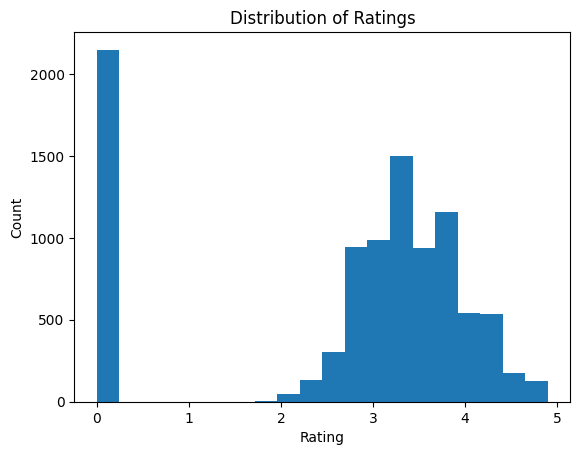

In [28]:
import matplotlib.pyplot as plt

plt.hist(df["Aggregate rating"], bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='City'>

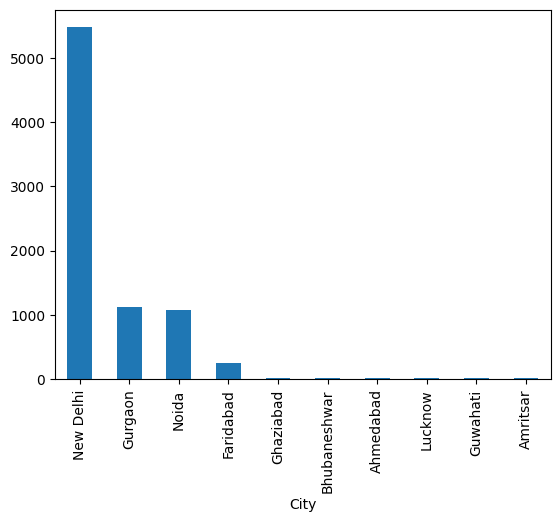

In [29]:
df["City"].value_counts().head(10).plot(kind="bar")

<Axes: xlabel='Cuisines'>

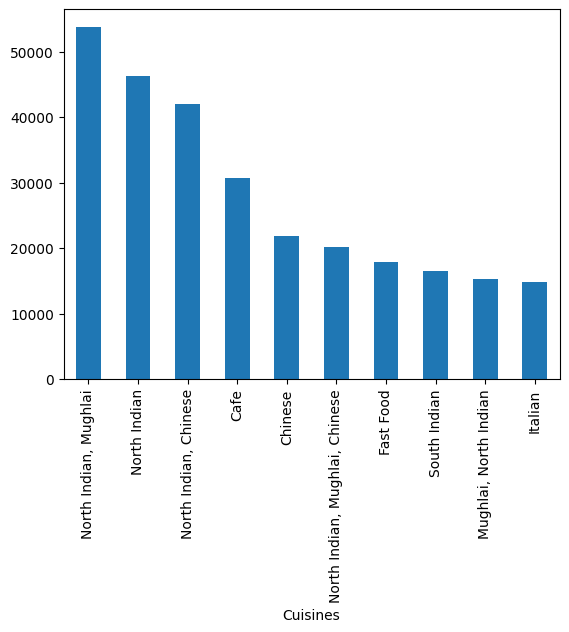

In [30]:
cuisine_votes.head(10).plot(kind="bar")

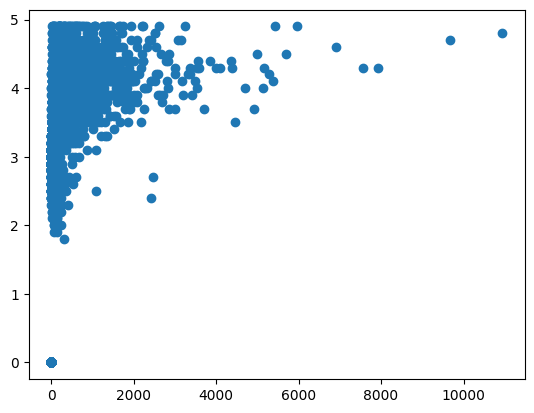

In [31]:
plt.scatter(
    df["Votes"],
    df["Aggregate rating"]
)

In [43]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
corr

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes,name_length,Has Table booking encoded,Has Online delivery encoded
Restaurant ID,1.000000,0.146270,-0.224362,-0.052626,-0.001629,-0.134528,-0.327160,-0.147434,-0.030088,-0.109794,-0.084615
Country Code,0.146270,1.000000,-0.694629,0.018049,0.043717,0.245363,0.281295,0.154361,0.063982,-0.060815,-0.153581
Longitude,-0.224362,-0.694629,1.000000,0.045415,0.045948,-0.080257,-0.114733,-0.084371,-0.070855,0.099860,0.177922
Latitude,-0.052626,0.018049,0.045415,1.000000,-0.111080,-0.166735,0.000197,-0.022914,0.040797,0.054874,0.119087
Average Cost for two,-0.001629,0.043717,0.045948,-0.111080,1.000000,0.075111,0.051864,0.067833,-0.004173,0.007733,-0.019017
Price range,-0.134528,0.245363,-0.080257,-0.166735,0.075111,1.000000,0.438356,0.309474,0.062452,0.502166,0.077887
Aggregate rating,-0.327160,0.281295,-0.114733,0.000197,0.051864,0.438356,1.000000,0.313474,-0.035282,0.190351,0.226250
Votes,-0.147434,0.154361,-0.084371,-0.022914,0.067833,0.309474,0.313474,1.000000,-0.018772,0.169619,0.074532
name_length,-0.030088,0.063982,-0.070855,0.040797,-0.004173,0.062452,-0.035282,-0.018772,1.000000,0.075795,-0.159585
Has Table booking encoded,-0.109794,-0.060815,0.099860,0.054874,0.007733,0.502166,0.190351,0.169619,0.075795,1.000000,0.101041


In [35]:
corr["Aggregate rating"].sort_values(ascending=False)

Aggregate rating               1.000000
Price range                    0.438356
Votes                          0.313474
Country Code                   0.281295
Has Online delivery encoded    0.226250
Has Table booking encoded      0.190351
Average Cost for two           0.051864
Latitude                       0.000197
name_length                   -0.035282
Longitude                     -0.114733
Restaurant ID                 -0.327160
Name: Aggregate rating, dtype: float64

### For the predictive model, I'd drop:

- Restaurant ID
- Latitude
- Longitude
- name_length

# Level 3 Task 1 - Predictive Modeling

In [44]:
features = [
    'Price range',
    'Votes',
    'Country Code',
    'Has Online delivery encoded',
    'Has Table booking encoded',
    'Average Cost for two'
]
X = df[features]
y = df["Aggregate rating"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression

In [51]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [53]:
y_pred = reg.predict(X_test)

In [56]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 1.0258083628972583
MSE: 1.5385034142361305
RMSE: 1.2403642264416248
R2: 0.32817389490386084


In [57]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [58]:
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", mean_squared_error(y_test, y_pred_dt)**0.5)
print("R2:", r2_score(y_test, y_pred_dt))

MAE: 0.2823297709935309
MSE: 0.1971828239792672
RMSE: 0.444052726575648
R2: 0.9138951741022807


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [60]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf)**0.5)
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 0.23106872154429833
MSE: 0.1270862700530423
RMSE: 0.35649161287896003
R2: 0.9445045925599569
